In [1]:
# ============================================================================
# CELL 1: IMPORTS
# ============================================================================
import json
import re
import os
import logging
import hashlib
from datetime import datetime, timedelta
from typing import Dict, List, Optional, Tuple, Any
from dataclasses import dataclass, field, asdict
from concurrent.futures import ThreadPoolExecutor, as_completed
from urllib.parse import urljoin, urlparse
import time
import warnings
warnings.filterwarnings('ignore')

# Third-party imports
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import feedparser
from bs4 import BeautifulSoup
import pandas as pd
from tqdm.notebook import tqdm
from newspaper import Article, Config as NewspaperConfig

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    handlers=[
        logging.FileHandler('scraper_v8_full.log', mode='w'),
    ]
)
logger = logging.getLogger(__name__)

print("✅ All imports loaded successfully")

✅ All imports loaded successfully


In [2]:
# ============================================================================
# CELL 2: CONFIGURATION - FULL SCRAPE MODE
# ============================================================================

SOURCES_FILE = "sources.json"

with open(SOURCES_FILE, 'r') as f:
    sources_data = json.load(f)
    SOURCES = [(s['name'], s['url']) for s in sources_data['sources']]

print(f"📰 Loaded {len(SOURCES)} sources from {SOURCES_FILE}")

# ─────────────────────────────────────────────────────────────────────────────
# FULL SCRAPE CONFIG - NO KEYWORD FILTER!
# ─────────────────────────────────────────────────────────────────────────────
CONFIG = {
    # Time settings - EXTENDED
    "date_range_days": 30,          # 30 days to get more articles
    "timeout_seconds": 15,          # Longer timeout
    "retry_count": 2,               # More retries
    
    # Parallelism settings
    "max_workers": None,            # Auto-detect
    "article_workers": 8,           # Workers for fetching article content
    
    # Discovery paths
    "rss_paths": [
        "/feed", "/rss", "/feeds/all.rss", "/rss.xml", "/feed.xml",
        "/atom.xml", "/index.xml", "/news/feed", "/blog/feed",
        "/feeds/posts/default", "/feed/", "/rss/"
    ],
    "api_paths": [
        "/api/articles", "/api/posts", "/api/news", "/api/v1/articles"
    ],
    
    # Quality thresholds - RELAXED
    "min_content_length": 100,      # Lower threshold
    "min_title_length": 5,          # Lower threshold
    
    # Time budgets per method (seconds) - EXTENDED
    "time_budget_rss": 60,
    "time_budget_api": 30,
    "time_budget_html": 90,
    "time_budget_homepage": 120,
    
    # Max articles per source
    "max_articles_per_source": 100,  # Cap per source
    
    # Output
    "output_file": "scraped_news_v8_FULL.csv",
    "telemetry_file": "scraping_telemetry_v8_FULL.csv"
}

# Auto-detect workers
if CONFIG["max_workers"] is None:
    CONFIG["max_workers"] = min(os.cpu_count() * 2, 16)

print(f"⚙️  FULL SCRAPE MODE - NO KEYWORD FILTER")
print(f"   • Date range: {CONFIG['date_range_days']} days")
print(f"   • Max per source: {CONFIG['max_articles_per_source']}")
print(f"   • Workers: {CONFIG['max_workers']}")

📰 Loaded 50 sources from sources.json
⚙️  FULL SCRAPE MODE - NO KEYWORD FILTER
   • Date range: 30 days
   • Max per source: 100
   • Workers: 16


In [3]:
# ============================================================================
# CELL 3: CORE UTILITIES
# ============================================================================

@dataclass
class ScrapedArticle:
    """Data class for a scraped article."""
    title: str
    url: str
    published_date: Optional[str] = None
    content: str = ""
    author: str = ""
    source_name: str = ""
    source_url: str = ""
    method: str = ""
    scrape_timestamp: str = field(default_factory=lambda: datetime.now().isoformat())

class HTTPClient:
    """Reusable HTTP client with session management."""
    
    def __init__(self, timeout: int = 10, retries: int = 1):
        self.timeout = timeout
        self.session = requests.Session()
        
        retry_strategy = Retry(
            total=retries,
            backoff_factor=0.5,
            status_forcelist=[429, 500, 502, 503, 504],
        )
        adapter = HTTPAdapter(max_retries=retry_strategy, pool_connections=20, pool_maxsize=20)
        self.session.mount("http://", adapter)
        self.session.mount("https://", adapter)
        
        self.session.headers.update({
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/120.0.0.0 Safari/537.36',
            'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8',
            'Accept-Language': 'en-US,en;q=0.9',
        })
    
    def get(self, url: str, **kwargs) -> Optional[requests.Response]:
        try:
            response = self.session.get(url, timeout=self.timeout, **kwargs)
            response.raise_for_status()
            return response
        except Exception as e:
            logger.debug(f"Request failed for {url}: {e}")
            return None
    
    def get_json(self, url: str) -> Optional[Dict]:
        try:
            response = self.get(url, headers={'Accept': 'application/json'})
            if response:
                return response.json()
        except Exception as e:
            logger.debug(f"JSON parse failed for {url}: {e}")
        return None

http = HTTPClient(timeout=CONFIG["timeout_seconds"], retries=CONFIG["retry_count"])

def parse_date(date_input: Any) -> Optional[datetime]:
    """Parse various date formats to datetime object."""
    if date_input is None:
        return None
    
    if hasattr(date_input, 'tm_year'):
        try:
            return datetime(*date_input[:6])
        except:
            return None
    
    if isinstance(date_input, datetime):
        return date_input
    
    if isinstance(date_input, str):
        date_formats = [
            "%Y-%m-%dT%H:%M:%S",
            "%Y-%m-%dT%H:%M:%SZ",
            "%Y-%m-%dT%H:%M:%S%z",
            "%Y-%m-%d %H:%M:%S",
            "%Y-%m-%d",
            "%d %b %Y",
            "%B %d, %Y",
            "%b %d, %Y",
        ]
        for fmt in date_formats:
            try:
                clean_date = re.sub(r'[+-]\d{2}:\d{2}$', '', date_input)
                clean_date = clean_date.replace('Z', '').strip()
                return datetime.strptime(clean_date, fmt)
            except:
                continue
    return None

def strip_html(text: str) -> str:
    """Strip HTML tags from text."""
    if not text:
        return ""
    soup = BeautifulSoup(text, 'html.parser')
    return soup.get_text(separator=' ')

def clean_text(text: str) -> str:
    """Clean and normalize text content."""
    if not text:
        return ""
    text = strip_html(text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def generate_article_hash(url: str, title: str) -> str:
    """Generate unique hash for deduplication."""
    content = f"{url.lower().strip()}{title.lower().strip()}"
    return hashlib.md5(content.encode()).hexdigest()

print("✅ Core utilities loaded")

✅ Core utilities loaded


In [4]:
# ============================================================================
# CELL 4: FEED DISCOVERY
# ============================================================================

def discover_rss_feed(base_url: str, paths: List[str]) -> Optional[str]:
    """Try to find RSS feed URL."""
    for path in paths:
        feed_url = urljoin(base_url, path)
        try:
            response = http.get(feed_url)
            if response and ('xml' in response.headers.get('content-type', '').lower() or
                           '<rss' in response.text[:500].lower() or
                           '<feed' in response.text[:500].lower()):
                return feed_url
        except:
            continue
    return None

def discover_api_endpoint(base_url: str, paths: List[str]) -> Optional[str]:
    """Try to find API endpoint."""
    for path in paths:
        api_url = urljoin(base_url, path)
        try:
            data = http.get_json(api_url)
            if data:
                return api_url
        except:
            continue
    return None

print("✅ Feed discovery loaded")

✅ Feed discovery loaded


In [5]:
# ============================================================================
# CELL 5: SCRAPERS - FULL MODE (NO KEYWORD FILTER)
# ============================================================================

newspaper_config = NewspaperConfig()
newspaper_config.browser_user_agent = http.session.headers['User-Agent']
newspaper_config.request_timeout = CONFIG["timeout_seconds"]
newspaper_config.fetch_images = False
newspaper_config.memoize_articles = False

def fetch_article_content(url: str) -> Tuple[str, str, str, Optional[datetime]]:
    """Fetch full article content using newspaper3k."""
    try:
        article = Article(url, config=newspaper_config)
        article.download()
        article.parse()
        
        title = article.title or ""
        content = clean_text(article.text or "")
        author = ", ".join(article.authors) if article.authors else ""
        pub_date = article.publish_date if article.publish_date else None
        
        return title, content, author, pub_date
    except Exception as e:
        logger.debug(f"Failed to fetch article {url}: {e}")
        return "", "", "", None

def scrape_rss(feed_url: str, source_name: str, source_url: str, 
               time_budget: float, max_articles: int) -> List[ScrapedArticle]:
    """Scrape ALL articles from RSS feed."""
    articles = []
    start_time = time.time()
    
    try:
        feed = feedparser.parse(feed_url)
        entries = feed.entries[:max_articles]  # Limit entries
        
        for entry in entries:
            if time.time() - start_time > time_budget:
                break
            
            title = entry.get('title', '')
            url = entry.get('link', '')
            
            if not url or not title:
                continue
            
            pub_date = parse_date(entry.get('published_parsed') or entry.get('updated_parsed'))
            author = entry.get('author', '') or entry.get('creator', '')
            
            raw_content = entry.get('summary', '') or entry.get('description', '')
            content = clean_text(raw_content)
            
            if len(content) < CONFIG["min_content_length"]:
                _, fetched_content, fetched_author, fetched_date = fetch_article_content(url)
                if fetched_content:
                    content = fetched_content
                if fetched_author and not author:
                    author = fetched_author
                if fetched_date and not pub_date:
                    pub_date = fetched_date
            
            articles.append(ScrapedArticle(
                title=title,
                url=url,
                published_date=pub_date.isoformat() if pub_date else None,
                content=content,
                author=author,
                source_name=source_name,
                source_url=source_url,
                method="rss"
            ))
    except Exception as e:
        logger.warning(f"RSS scrape failed for {source_name}: {e}")
    
    return articles

def scrape_api(api_url: str, source_name: str, source_url: str,
               time_budget: float, max_articles: int) -> List[ScrapedArticle]:
    """Scrape ALL articles from API endpoint."""
    articles = []
    start_time = time.time()
    
    try:
        data = http.get_json(api_url)
        if not data:
            return []
        
        items = data if isinstance(data, list) else data.get('articles', data.get('posts', data.get('items', data.get('data', []))))
        
        for item in items[:max_articles]:
            if time.time() - start_time > time_budget:
                break
            
            title = item.get('title') or item.get('headline', '')
            url = item.get('url') or item.get('link', '')
            
            if not url or not title:
                continue
            
            if not url.startswith('http'):
                url = urljoin(source_url, url)
            
            pub_date = parse_date(item.get('published_at') or item.get('date') or item.get('publishedAt'))
            author = item.get('author') or item.get('author_name', '')
            content = item.get('content') or item.get('body') or item.get('description', '')
            
            if len(content) < CONFIG["min_content_length"]:
                _, fetched_content, fetched_author, fetched_date = fetch_article_content(url)
                if fetched_content:
                    content = fetched_content
                if fetched_author and not author:
                    author = fetched_author
                if fetched_date and not pub_date:
                    pub_date = fetched_date
            
            articles.append(ScrapedArticle(
                title=title,
                url=url,
                published_date=pub_date.isoformat() if pub_date else None,
                content=clean_text(content),
                author=author,
                source_name=source_name,
                source_url=source_url,
                method="api"
            ))
    except Exception as e:
        logger.warning(f"API scrape failed for {source_name}: {e}")
    
    return articles

def scrape_html(base_url: str, source_name: str, time_budget: float, max_articles: int) -> List[ScrapedArticle]:
    """Scrape articles by finding article links in HTML."""
    articles = []
    start_time = time.time()
    
    try:
        response = http.get(base_url)
        if not response:
            return []
        
        soup = BeautifulSoup(response.text, 'html.parser')
        
        article_selectors = [
            'article a[href]',
            '.article a[href]',
            '.post a[href]',
            '.story a[href]',
            'a[href*="/article/"]',
            'a[href*="/news/"]',
            'a[href*="/story/"]',
            'a[href*="/post/"]',
            'a[href*="/20"]',  # Date-based URLs
        ]
        
        seen_urls = set()
        links = []
        
        for selector in article_selectors:
            for link in soup.select(selector):
                href = link.get('href', '')
                if href and href not in seen_urls:
                    full_url = urljoin(base_url, href)
                    if urlparse(full_url).netloc == urlparse(base_url).netloc:
                        seen_urls.add(href)
                        links.append(full_url)
        
        def fetch_one(url):
            if time.time() - start_time > time_budget:
                return None
            title, content, author, pub_date = fetch_article_content(url)
            if title and len(content) >= CONFIG["min_content_length"]:
                return ScrapedArticle(
                    title=title,
                    url=url,
                    published_date=pub_date.isoformat() if pub_date else None,
                    content=content,
                    author=author,
                    source_name=source_name,
                    source_url=base_url,
                    method="html"
                )
            return None
        
        with ThreadPoolExecutor(max_workers=CONFIG["article_workers"]) as executor:
            futures = [executor.submit(fetch_one, url) for url in links[:max_articles]]
            for future in as_completed(futures):
                try:
                    result = future.result()
                    if result:
                        articles.append(result)
                except:
                    pass
    except Exception as e:
        logger.warning(f"HTML scrape failed for {source_name}: {e}")
    
    return articles

def scrape_homepage(base_url: str, source_name: str, time_budget: float, max_articles: int) -> List[ScrapedArticle]:
    """Scrape articles directly from homepage links."""
    articles = []
    start_time = time.time()
    
    try:
        response = http.get(base_url)
        if not response:
            return []
        
        soup = BeautifulSoup(response.text, 'html.parser')
        
        all_links = soup.find_all('a', href=True)
        article_urls = []
        
        for link in all_links:
            href = link.get('href', '')
            full_url = urljoin(base_url, href)
            
            parsed = urlparse(full_url)
            if parsed.netloc != urlparse(base_url).netloc:
                continue
            
            path = parsed.path.lower()
            if any(skip in path for skip in ['/tag/', '/category/', '/author/', '/login', '/signup', '/subscribe', '/search']):
                continue
            if any(pattern in path for pattern in ['/20', '/article', '/news/', '/story/', '/post/', '/blog/']):
                if full_url not in article_urls:
                    article_urls.append(full_url)
        
        def fetch_one(url):
            if time.time() - start_time > time_budget:
                return None
            title, content, author, pub_date = fetch_article_content(url)
            if title and len(content) >= CONFIG["min_content_length"]:
                return ScrapedArticle(
                    title=title,
                    url=url,
                    published_date=pub_date.isoformat() if pub_date else None,
                    content=content,
                    author=author,
                    source_name=source_name,
                    source_url=base_url,
                    method="homepage"
                )
            return None
        
        with ThreadPoolExecutor(max_workers=CONFIG["article_workers"]) as executor:
            futures = [executor.submit(fetch_one, url) for url in article_urls[:max_articles]]
            for future in as_completed(futures):
                try:
                    result = future.result()
                    if result:
                        articles.append(result)
                except:
                    pass
    except Exception as e:
        logger.warning(f"Homepage scrape failed for {source_name}: {e}")
    
    return articles

print("✅ Scraper functions loaded (FULL MODE - no keyword filter)")

✅ Scraper functions loaded (FULL MODE - no keyword filter)


In [6]:
# ============================================================================
# CELL 6: MINIMAL FILTERS (Quality only, NO keywords)
# ============================================================================

def filter_by_quality(articles: List[ScrapedArticle], 
                      min_content_length: int = 100,
                      min_title_length: int = 5) -> List[ScrapedArticle]:
    """Filter articles by quality thresholds only."""
    return [
        a for a in articles
        if len(a.content) >= min_content_length and len(a.title) >= min_title_length
    ]

def deduplicate(articles: List[ScrapedArticle]) -> List[ScrapedArticle]:
    """Remove duplicate articles based on URL and title."""
    seen_hashes = set()
    unique = []
    
    for article in articles:
        article_hash = generate_article_hash(article.url, article.title)
        if article_hash not in seen_hashes:
            seen_hashes.add(article_hash)
            unique.append(article)
    
    return unique

print("✅ Filters loaded (quality only - NO keyword filter)")

✅ Filters loaded (quality only - NO keyword filter)


In [7]:
# ============================================================================
# CELL 7: SOURCE SCRAPING LOGIC
# ============================================================================

@dataclass
class SourceResult:
    """Result from scraping a single source."""
    source_name: str
    source_url: str
    method_used: str
    articles_found: int
    articles_after_filter: int
    elapsed_seconds: float
    success: bool
    error: str = ""

def scrape_single_source(source_name: str, source_url: str) -> Tuple[List[ScrapedArticle], SourceResult]:
    """Scrape a single source using best available method."""
    start_time = time.time()
    articles = []
    method_used = "none"
    error = ""
    max_articles = CONFIG["max_articles_per_source"]
    
    try:
        # Try RSS first
        feed_url = discover_rss_feed(source_url, CONFIG["rss_paths"])
        if feed_url:
            articles = scrape_rss(feed_url, source_name, source_url, CONFIG["time_budget_rss"], max_articles)
            if articles:
                method_used = "rss"
        
        # Try API if RSS failed
        if not articles:
            api_url = discover_api_endpoint(source_url, CONFIG["api_paths"])
            if api_url:
                articles = scrape_api(api_url, source_name, source_url, CONFIG["time_budget_api"], max_articles)
                if articles:
                    method_used = "api"
        
        # Try HTML parsing
        if not articles:
            articles = scrape_html(source_url, source_name, CONFIG["time_budget_html"], max_articles)
            if articles:
                method_used = "html"
        
        # Last resort: homepage scraping
        if not articles:
            articles = scrape_homepage(source_url, source_name, CONFIG["time_budget_homepage"], max_articles)
            if articles:
                method_used = "homepage"
        
    except Exception as e:
        error = str(e)
        logger.error(f"Error scraping {source_name}: {e}")
    
    elapsed = time.time() - start_time
    
    # Apply ONLY quality filter (no keyword filter!)
    original_count = len(articles)
    articles = filter_by_quality(articles, CONFIG["min_content_length"], CONFIG["min_title_length"])
    articles = deduplicate(articles)
    
    result = SourceResult(
        source_name=source_name,
        source_url=source_url,
        method_used=method_used,
        articles_found=original_count,
        articles_after_filter=len(articles),
        elapsed_seconds=elapsed,
        success=len(articles) > 0,
        error=error
    )
    
    return articles, result

print("✅ Source scraping logic loaded")

✅ Source scraping logic loaded


In [8]:
# ============================================================================
# CELL 8: PARALLEL ORCHESTRATOR
# ============================================================================

def scrape_all_sources_parallel(sources: List[Tuple[str, str]], 
                                 max_workers: int = 16) -> Tuple[List[ScrapedArticle], List[SourceResult]]:
    """Scrape all sources in parallel."""
    all_articles = []
    all_results = []
    
    print(f"\n🚀 Starting FULL parallel scrape with {max_workers} workers...")
    print(f"📰 Processing {len(sources)} sources (NO keyword filter)\n")
    
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_source = {
            executor.submit(scrape_single_source, name, url): (name, url)
            for name, url in sources
        }
        
        with tqdm(total=len(sources), desc="Scraping sources", unit="source") as pbar:
            for future in as_completed(future_to_source):
                source_name, source_url = future_to_source[future]
                
                try:
                    articles, result = future.result()
                    all_articles.extend(articles)
                    all_results.append(result)
                except Exception as e:
                    logger.error(f"Failed to process {source_name}: {e}")
                    all_results.append(SourceResult(
                        source_name=source_name,
                        source_url=source_url,
                        method_used="none",
                        articles_found=0,
                        articles_after_filter=0,
                        elapsed_seconds=0,
                        success=False,
                        error=str(e)
                    ))
                
                pbar.update(1)
    
    # Final deduplication
    all_articles = deduplicate(all_articles)
    
    return all_articles, all_results

print("✅ Orchestrator loaded")

✅ Orchestrator loaded


In [9]:
# ============================================================================
# CELL 9: MAIN EXECUTION - FULL SCRAPE
# ============================================================================

print("=" * 70)
print("🚀 V8 NEWS SCRAPER - FULL SCRAPE MODE (NO KEYWORDS)")
print("=" * 70)
print(f"⏰ Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"📰 Sources: {len(SOURCES)}")
print(f"📅 Date range: {CONFIG['date_range_days']} days")
print(f"🔑 Keywords: DISABLED (scraping everything)")
print(f"⚡ Workers: {CONFIG['max_workers']}")
print(f"📦 Max per source: {CONFIG['max_articles_per_source']}")
print("=" * 70)

# Run the parallel scraper
scrape_start = time.time()

all_articles, telemetry = scrape_all_sources_parallel(
    sources=SOURCES,
    max_workers=CONFIG["max_workers"]
)

total_time = time.time() - scrape_start

print("\n" + "=" * 70)
print("✅ FULL SCRAPING COMPLETE")
print("=" * 70)
print(f"⏱️  Total time: {total_time/60:.1f} minutes ({total_time:.0f} seconds)")
print(f"📊 Total articles collected: {len(all_articles)}")
print(f"✓  Successful sources: {sum(1 for r in telemetry if r.success)}/{len(telemetry)}")
print("=" * 70)

🚀 V8 NEWS SCRAPER - FULL SCRAPE MODE (NO KEYWORDS)
⏰ Started at: 2025-12-15 03:25:15
📰 Sources: 50
📅 Date range: 30 days
🔑 Keywords: DISABLED (scraping everything)
⚡ Workers: 16
📦 Max per source: 100

🚀 Starting FULL parallel scrape with 16 workers...
📰 Processing 50 sources (NO keyword filter)



Scraping sources:   0%|          | 0/50 [00:00<?, ?source/s]


✅ FULL SCRAPING COMPLETE
⏱️  Total time: 4.9 minutes (292 seconds)
📊 Total articles collected: 1297
✓  Successful sources: 40/50


In [11]:
# ============================================================================
# CELL 10: EXPORT TO CSV
# ============================================================================

# Convert articles to DataFrame
articles_data = [asdict(article) for article in all_articles]
df_articles = pd.DataFrame(articles_data)

# Export format
df_export = pd.DataFrame({
    'source': df_articles['source_name'],
    'headline': df_articles['title'],
    'author': df_articles['author'] if 'author' in df_articles.columns else '',
    'url': df_articles['url'],
    'published': df_articles['published_date'],
    'content_snippet': df_articles['content'].str[:200],
    'url_hash': df_articles['url'].apply(lambda x: hashlib.md5(x.encode()).hexdigest()[:8]),
    'full_content': df_articles['content'],
    'method': df_articles['method'],
    'scraped_at': df_articles['scrape_timestamp']
})

# Save articles CSV
df_export.to_csv(CONFIG["output_file"], index=False, encoding='utf-8')
print(f"✅ Articles saved to: {CONFIG['output_file']}")
print(f"   • Total rows: {len(df_export)}")

# Save telemetry CSV
telemetry_data = [asdict(r) for r in telemetry]
df_telemetry = pd.DataFrame(telemetry_data)
df_telemetry.to_csv(CONFIG["telemetry_file"], index=False, encoding='utf-8')
print(f"✅ Telemetry saved to: {CONFIG['telemetry_file']}")

# Preview
print("\n📰 Sample articles:")
if not df_export.empty:
    display(df_export[['headline', 'source', 'method', 'published']].head(10))

✅ Articles saved to: scraped_news_v8_FULL.csv
   • Total rows: 1297
✅ Telemetry saved to: scraping_telemetry_v8_FULL.csv

📰 Sample articles:


,headline,source,method,published
0,Is ChatGPT’s New Shopping Research Solving a P...,The Next Web,rss,2025-12-11T22:37:55
1,Tekpon acquires TNW (The Next Web) brand from ...,The Next Web,rss,2025-12-08T19:27:33
2,Ending graciously,The Next Web,rss,2025-09-29T12:00:55
3,How robotics could turn e-waste into a tech go...,The Next Web,rss,2025-09-24T09:00:37
4,Startup wisdom: 5 prompt engineering tips for ...,The Next Web,rss,2025-09-24T06:03:18
5,How European battery startups can thrive along...,The Next Web,rss,2025-09-23T09:00:30
6,The EU’s €2T budget overlooks a key tech pilla...,The Next Web,rss,2025-09-23T08:30:32
7,Opinion: Europe’s VCs must embrace risk — or r...,The Next Web,rss,2025-09-22T08:00:41
8,VCs are growing wary of ‘AI-washing’ – but rea...,The Next Web,rss,2025-09-18T10:00:37
9,Opinion: Ukraine is becoming a global defence ...,The Next Web,rss,2025-09-17T14:00:51


In [12]:
# ============================================================================
# CELL 11: ANALYTICS - ARTICLES PER SOURCE
# ============================================================================

print("=" * 70)
print("📊 FULL SCRAPE ANALYTICS")
print("=" * 70)

# Articles per source
print("\n📰 Articles per Source (Top 20):")
source_counts = df_articles.groupby('source_name').size().sort_values(ascending=False)
for source, count in source_counts.head(20).items():
    print(f"   • {source:30} : {count:4} articles")

print(f"\n📈 Total sources with articles: {len(source_counts)}")
print(f"📈 Average articles per source: {source_counts.mean():.1f}")
print(f"📈 Max articles from one source: {source_counts.max()}")
print(f"📈 Min articles from one source: {source_counts.min()}")

# Method breakdown
print("\n📈 Articles by Method:")
method_counts = df_articles.groupby('method').size().sort_values(ascending=False)
for method, count in method_counts.items():
    pct = count / len(df_articles) * 100 if len(df_articles) > 0 else 0
    print(f"   • {method.upper():10} : {count:4} articles ({pct:.1f}%)")

# Failed sources
print("\n❌ Failed Sources:")
failed = [r for r in telemetry if not r.success]
if failed:
    for r in failed[:15]:
        print(f"   • {r.source_name}: {r.error[:50] if r.error else 'No articles found'}")
    if len(failed) > 15:
        print(f"   ... and {len(failed) - 15} more")
else:
    print("   All sources succeeded!")

print("\n" + "=" * 70)

📊 FULL SCRAPE ANALYTICS

📰 Articles per Source (Top 20):
   • Electrek                       :  100 articles
   • The Guardian Tech              :   99 articles
   • BBC Technology                 :   95 articles
   • Mashable                       :   95 articles
   • The Atlantic Tech              :   72 articles
   • CNBC Tech                      :   70 articles
   • NPR Tech                       :   68 articles
   • AP Tech                        :   60 articles
   • CNN Tech                       :   54 articles
   • Engadget                       :   50 articles
   • TechRadar                      :   50 articles
   • NY Times Tech                  :   46 articles
   • CleanTechnica                  :   45 articles
   • AI Business                    :   35 articles
   • IEEE Spectrum                  :   30 articles
   • Digital Trends                 :   30 articles
   • Tom's Hardware                 :   27 articles
   • Gizmodo                        :   20 articles
   • ZD

In [13]:
# ============================================================================
# CELL 12: DETAILED SOURCE REPORT
# ============================================================================

print("📋 DETAILED SOURCE REPORT")
print("=" * 90)
print(f"{'Source':<35} {'Method':<10} {'Found':<8} {'After Filter':<12} {'Time':<8}")
print("-" * 90)

# Sort by articles found
sorted_telemetry = sorted(telemetry, key=lambda x: x.articles_after_filter, reverse=True)

for r in sorted_telemetry:
    status = "✅" if r.success else "❌"
    print(f"{status} {r.source_name:<33} {r.method_used:<10} {r.articles_found:<8} {r.articles_after_filter:<12} {r.elapsed_seconds:.1f}s")

print("-" * 90)
total_found = sum(r.articles_found for r in telemetry)
total_after = sum(r.articles_after_filter for r in telemetry)
print(f"{'TOTAL':<35} {'':<10} {total_found:<8} {total_after:<12}")

📋 DETAILED SOURCE REPORT
Source                              Method     Found    After Filter Time    
------------------------------------------------------------------------------------------
✅ Electrek                          rss        100      100          2.5s
✅ The Guardian Tech                 rss        100      99           7.4s
✅ Mashable                          rss        95       95           65.0s
✅ BBC Technology                    html       97       95           65.0s
✅ The Atlantic Tech                 html       72       72           120.7s
✅ CNBC Tech                         html       70       70           88.5s
✅ NPR Tech                          html       70       68           69.9s
✅ AP Tech                           html       60       60           123.3s
✅ CNN Tech                          html       54       54           115.1s
✅ Engadget                          rss        50       50           10.7s
✅ TechRadar                         rss        50      

Total articles: 1297
Content length (mean, median, min, max): 2441.7023901310718 508.0 100 84798
Title length (mean, median, min, max): 69.97609868928296 69.0 5 216


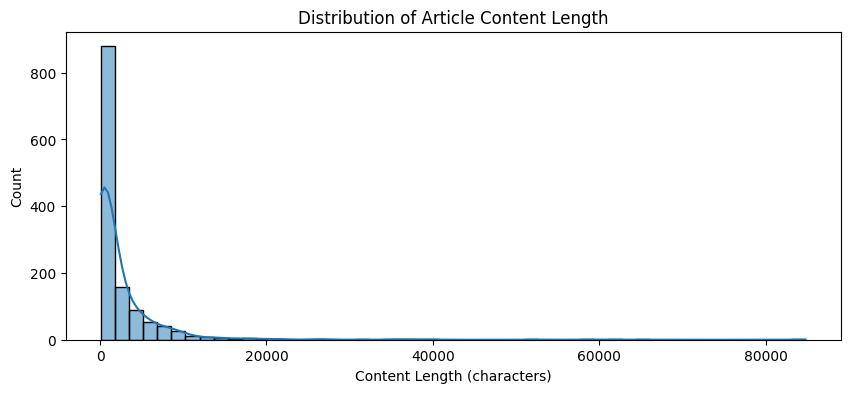

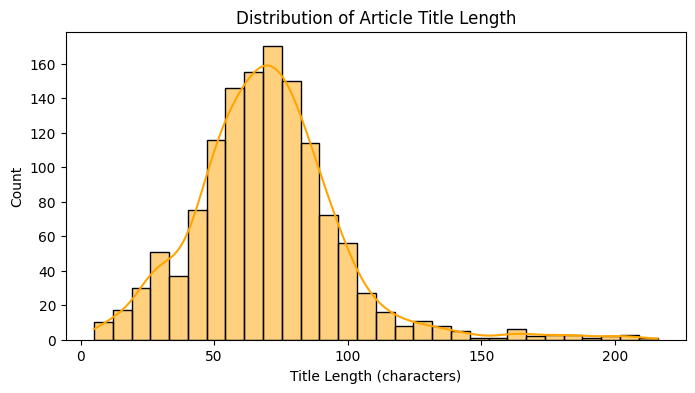


Sample articles:


,title,content_length,title_length
0,Is ChatGPT’s New Shopping Research Solving a P...,663,70
1,Tekpon acquires TNW (The Next Web) brand from ...,676,65
2,Ending graciously,577,17
3,How robotics could turn e-waste into a tech go...,654,52
4,Startup wisdom: 5 prompt engineering tips for ...,711,65
5,How European battery startups can thrive along...,755,63
6,The EU’s €2T budget overlooks a key tech pilla...,716,60
7,Opinion: Europe’s VCs must embrace risk — or r...,623,76
8,VCs are growing wary of ‘AI-washing’ – but rea...,629,85
9,Opinion: Ukraine is becoming a global defence ...,745,61


In [15]:
# ============================================================================
# CELL: DATA ANALYTICS OF SCRAPED OUTPUT
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Convert all_articles to DataFrame
articles_df = pd.DataFrame([a.__dict__ for a in all_articles])

# Add length columns
articles_df['content_length'] = articles_df['content'].str.len()
articles_df['title_length'] = articles_df['title'].str.len()

# Basic stats
print('Total articles:', len(articles_df))
print('Content length (mean, median, min, max):',
      articles_df['content_length'].mean(),
      articles_df['content_length'].median(),
      articles_df['content_length'].min(),
      articles_df['content_length'].max())
print('Title length (mean, median, min, max):',
      articles_df['title_length'].mean(),
      articles_df['title_length'].median(),
      articles_df['title_length'].min(),
      articles_df['title_length'].max())

# Plot content length distribution
plt.figure(figsize=(10,4))
sns.histplot(articles_df['content_length'], bins=50, kde=True)
plt.title('Distribution of Article Content Length')
plt.xlabel('Content Length (characters)')
plt.ylabel('Count')
plt.show()

# Plot title length distribution
plt.figure(figsize=(8,4))
sns.histplot(articles_df['title_length'], bins=30, kde=True, color='orange')
plt.title('Distribution of Article Title Length')
plt.xlabel('Title Length (characters)')
plt.ylabel('Count')
plt.show()

# Show a few examples
print('\nSample articles:')
display(articles_df[['title', 'content_length', 'title_length']].head(10))

In [16]:
# ============================================================================
# CELL: INVESTIGATE LONG CONTENT ARTICLES
# ============================================================================

# Find the longest articles
longest_articles = articles_df.nlargest(5, 'content_length')[['title', 'source_name', 'content_length', 'content']]

print("🔍 LONGEST ARTICLES INVESTIGATION")
print("=" * 80)

for idx, row in longest_articles.iterrows():
    print(f"\n📄 Article {idx+1}: {row['title'][:80]}...")
    print(f"   Source: {row['source_name']}")
    print(f"   Length: {row['content_length']} characters")
    print(f"   Content preview (first 500 chars):")
    content_preview = row['content'][:500].replace('\n', ' ').replace('\r', ' ')
    print(f"   '{content_preview}...'")
    print("-" * 80)

# Check for whitespace issues
print("\n🔍 WHITESPACE ANALYSIS")
print("=" * 80)

# Sample some long articles to check for excessive whitespace
sample_long = articles_df[articles_df['content_length'] > 10000].head(3)
for idx, row in sample_long.iterrows():
    content = row['content']
    lines = content.split('\n')
    spaces = content.count(' ')
    newlines = content.count('\n')
    tabs = content.count('\t')

    print(f"\nArticle: {row['title'][:50]}...")
    print(f"   Total chars: {len(content)}")
    print(f"   Spaces: {spaces}")
    print(f"   Newlines: {newlines}")
    print(f"   Tabs: {tabs}")
    print(f"   Lines: {len(lines)}")
    print(f"   Avg chars per line: {len(content)/len(lines):.1f}")

print("\n" + "=" * 80)

🔍 LONGEST ARTICLES INVESTIGATION

📄 Article 1149: THE 100 BEST MOVIES OF THE 21st CENTURY...
   Source: NY Times Tech
   Length: 84798 characters
   Content preview (first 500 chars):
   'More than 500 influential directors, actors and other notable names in Hollywood and around the world voted on the best films released since Jan. 1, 2000. Here is how their ballots stacked up. Voters included Oscar-winning directors like Pedro Almodóvar, Sofia Coppola, Barry Jenkins and Guillermo del Toro, as well as acclaimed actors like Chiwetel Ejiofor and Mikey Madison, John Turturro and Julianne Moore. Now you can finally see the full list. Enjoy! To find out, we embarked on an ambitious ne...'
--------------------------------------------------------------------------------

📄 Article 1296: Why Is Robert F. Kennedy Jr. So Convinced He’s Right?...
   Source: The Atlantic Tech
   Length: 65136 characters
   Content preview (first 500 chars):
   'This article was featured in the One Story to Read To